# Object Detection

## Overview

Object detection simultaneously localises (bounding box) and classifies (label) multiple objects within an image. It extends classification from "what is in this image" to "what is where".

**Key concepts:**

| Concept | Meaning |
|---|---|
| Bounding box | (x_min, y_min, x_max, y_max) or (cx, cy, w, h) |
| IoU (Intersection over Union) | Overlap measure; IoU > 0.5 = good match |
| Anchor boxes | Pre-defined box shapes tiled across the image |
| NMS (Non-Maximum Suppression) | Remove duplicate detections |
| mAP | Mean Average Precision across IoU thresholds and classes |

**Architecture families:**
- Two-stage: Faster R-CNN — region proposals then classification (accurate, slower)
- One-stage: YOLO, SSD — direct prediction (fast, slightly less accurate)
- Transformer-based: DETR — end-to-end, no NMS needed

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn

rng = np.random.default_rng(42)

# Simulate annotated ecological image dataset
# Objects: "sensor_marker", "vegetation_patch", "erosion_scar"
CLASS_NAMES = ['background', 'sensor_marker', 'vegetation_patch', 'erosion_scar']

def make_annotated_image(n_objects=3, img_size=256, seed=0):
    r = np.random.default_rng(seed)
    img   = r.integers(80, 140, (img_size, img_size, 3), dtype=np.uint8)
    boxes, class_ids = [], []
    for _ in range(n_objects):
        cls   = r.integers(1, 4)
        x1    = r.integers(10, img_size - 60)
        y1    = r.integers(10, img_size - 60)
        w     = r.integers(20, min(80, img_size - x1 - 5))
        h     = r.integers(20, min(80, img_size - y1 - 5))
        x2, y2 = x1 + w, y1 + h
        # Draw coloured rectangle for the object
        colours = {1: [200,50,50], 2: [50,180,50], 3: [50,50,200]}
        img[y1:y2, x1:x2] = colours[cls]
        boxes.append([x1, y1, x2, y2])
        class_ids.append(cls)
    return img, np.array(boxes), np.array(class_ids)

imgs_ann = [make_annotated_image(n_objects=rng.integers(1,5), seed=i) for i in range(6)]
print(f"Generated {len(imgs_ann)} annotated images")
print(f"Sample: img={imgs_ann[0][0].shape}, boxes={imgs_ann[0][1]}, classes={imgs_ann[0][2]}")

Generated 6 annotated images
Sample: img=(256, 256, 3), boxes=[[ 18  84  76 144]], classes=[3]


---
## IoU and NMS Implementation

In [2]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0]); y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2]); y2 = min(box1[3], box2[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / (union + 1e-8)

def nms(boxes, scores, iou_threshold=0.5):
    if len(boxes) == 0: return []
    boxes, scores = np.array(boxes), np.array(scores)
    order = np.argsort(scores)[::-1]
    keep  = []
    while len(order):
        i = order[0]; keep.append(i)
        ious = np.array([compute_iou(boxes[i], boxes[j]) for j in order[1:]])
        order = order[1:][ious < iou_threshold]
    return keep

# Demo: NMS removes overlapping detections
test_boxes  = [[50,50,150,150],[60,60,155,155],[200,200,280,280],[205,205,285,285]]
test_scores = [0.9, 0.7, 0.85, 0.6]
kept = nms(test_boxes, test_scores, iou_threshold=0.5)
print("Before NMS:", list(range(len(test_boxes))), "scores:", test_scores)
print("After NMS (kept):", kept, "scores:", [test_scores[i] for i in kept])
iou_eg = compute_iou(test_boxes[0], test_boxes[1])
print(f"IoU(box0, box1) = {iou_eg:.3f}  (high -> suppressed by NMS)")
iou_far = compute_iou(test_boxes[0], test_boxes[2])
print(f"IoU(box0, box2) = {iou_far:.3f} (low -> both kept)")

Before NMS: [0, 1, 2, 3] scores: [0.9, 0.7, 0.85, 0.6]
After NMS (kept): [np.int64(0), np.int64(2)] scores: [0.9, 0.85]
IoU(box0, box1) = 0.741  (high -> suppressed by NMS)
IoU(box0, box2) = 0.000 (low -> both kept)


---
## Visualising Detections

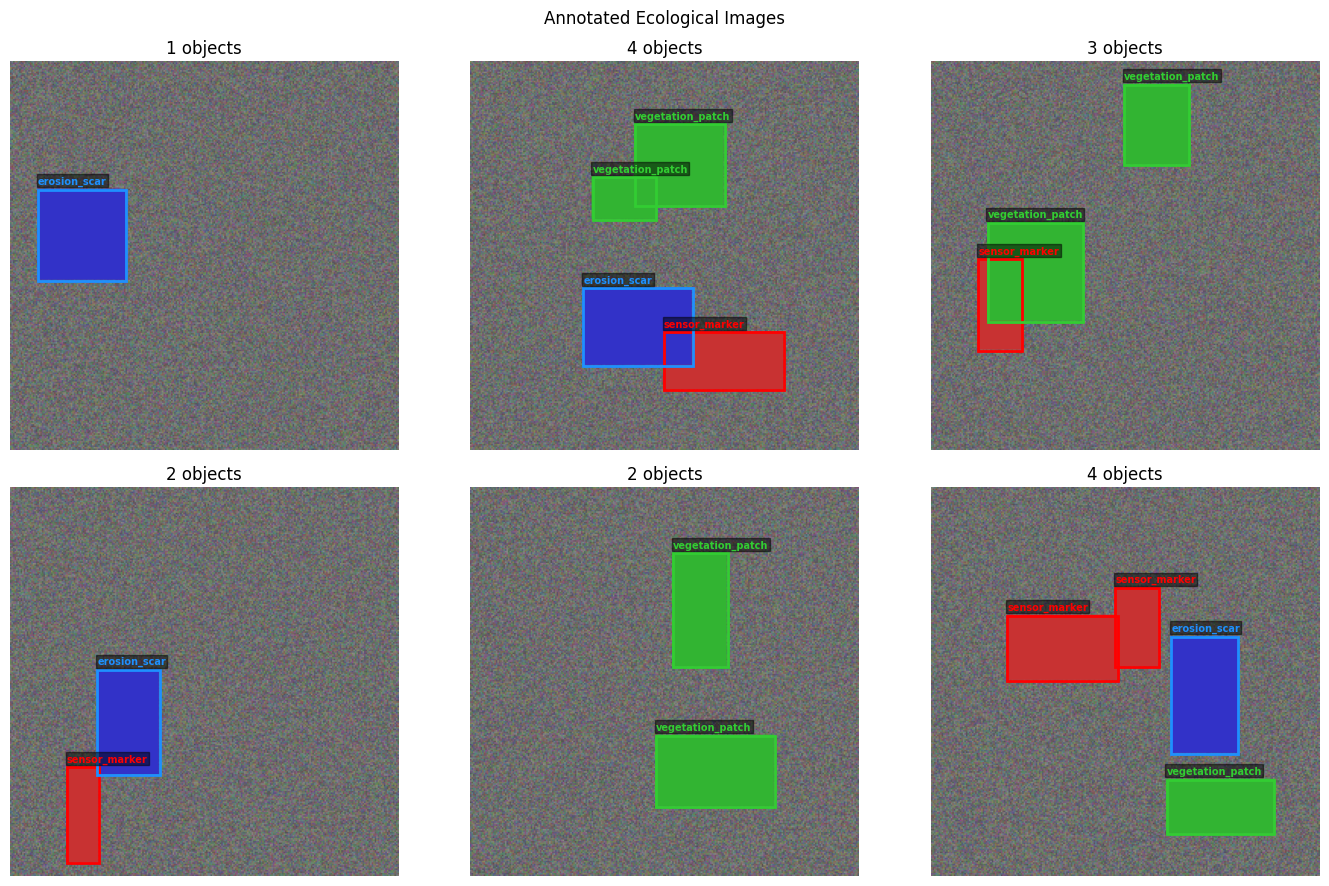

In [3]:
def draw_boxes(ax, img, boxes, class_ids, scores=None, title=''):
    ax.imshow(img)
    colors = {1:'red', 2:'limegreen', 3:'dodgerblue'}
    for i, (box, cls) in enumerate(zip(boxes, class_ids)):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=colors.get(cls,'white'), facecolor='none')
        ax.add_patch(rect)
        label = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)
        if scores is not None:
            label += f' {scores[i]:.2f}'
        ax.text(x1, y1-4, label, color=colors.get(cls,'white'),
                fontsize=7, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.5, pad=1))
    ax.axis('off'); ax.set_title(title)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (img, boxes, cls_ids) in zip(axes.ravel(), imgs_ann):
    draw_boxes(ax, img, boxes, cls_ids, title=f'{len(boxes)} objects')
plt.suptitle('Annotated Ecological Images'); plt.tight_layout(); plt.show()

---
## Using Torchvision Faster R-CNN

In [4]:
try:
    import torchvision
    from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    # Load pretrained Faster R-CNN
    model_det = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    # Replace head for custom number of classes
    in_features = model_det.roi_heads.box_predictor.cls_score.in_features
    model_det.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=4)
    total = sum(p.numel() for p in model_det.parameters())
    trainable = sum(p.numel() for p in model_det.parameters() if p.requires_grad)
    print(f"Faster R-CNN: {total:,} params, {trainable:,} trainable")
    # Inference format
    model_det.eval()
    dummy_img = [torch.rand(3, 256, 256)]
    with torch.no_grad():
        preds = model_det(dummy_img)
    print(f"\nPrediction keys: {list(preds[0].keys())}")
    print(f"  boxes:  {preds[0]['boxes'].shape}")
    print(f"  labels: {preds[0]['labels'].shape}")
    print(f"  scores: {preds[0]['scores'].shape}")
    print("\nTraining format: model([img1, img2], [target1, target2])")
    print("  target = {'boxes': FloatTensor (N,4), 'labels': IntTensor (N,)}")
except ImportError:
    print("pip install torchvision")
    print("Faster R-CNN usage:")
    print("  model = fasterrcnn_resnet50_fpn(weights='DEFAULT')")
    print("  model.roi_heads.box_predictor = FastRCNNPredictor(in_feats, n_classes)")
    print("  Training: model([imgs], [targets]) returns loss dict")
    print("  Inference: model.eval(); model([imgs]) returns prediction dicts")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\saman/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:03<00:00, 44.7MB/s] 


Faster R-CNN: 41,309,411 params, 41,087,011 trainable

Prediction keys: ['boxes', 'labels', 'scores']
  boxes:  torch.Size([100, 4])
  labels: torch.Size([100])
  scores: torch.Size([100])

Training format: model([img1, img2], [target1, target2])
  target = {'boxes': FloatTensor (N,4), 'labels': IntTensor (N,)}


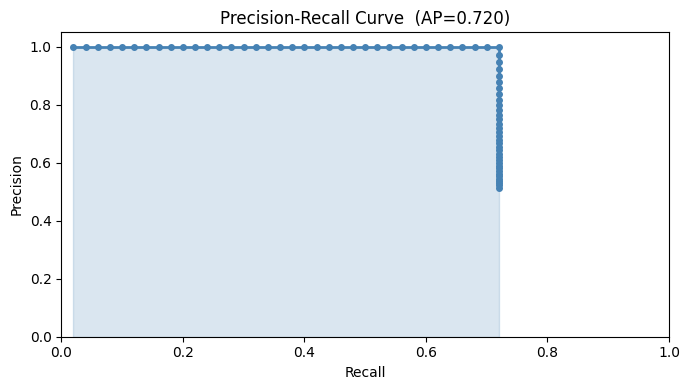

AP = 0.720  (area under precision-recall curve)
mAP = mean AP across all classes and IoU thresholds
COCO mAP uses IoU thresholds [0.50, 0.55, ..., 0.95]


In [5]:
# mAP (Mean Average Precision) implementation
def compute_ap(recalls, precisions):
    recalls    = np.concatenate([[0], recalls,    [1]])
    precisions = np.concatenate([[0], precisions, [0]])
    for i in range(len(precisions)-2, -1, -1):
        precisions[i] = max(precisions[i], precisions[i+1])
    idx = np.where(recalls[1:] != recalls[:-1])[0] + 1
    return np.sum((recalls[idx] - recalls[idx-1]) * precisions[idx])

# Simulate predictions vs ground truth for mAP demo
rng2 = np.random.default_rng(7)
n_gt  = 50
# Simulate: 50 true objects, model produces 70 detections with varying confidence
gt_labels  = rng2.integers(1, 4, n_gt)
pred_scores = rng2.uniform(0.1, 1.0, 70)
# True positives: high-score preds more likely correct
is_tp = pred_scores > 0.55   # simplified: high confidence = TP
pred_scores_sorted = np.sort(pred_scores)[::-1]
is_tp_sorted       = is_tp[np.argsort(pred_scores)[::-1]]
cum_tp   = np.cumsum(is_tp_sorted)
cum_fp   = np.cumsum(~is_tp_sorted)
precision = cum_tp / (cum_tp + cum_fp + 1e-8)
recall    = cum_tp / n_gt
ap = compute_ap(recall, precision)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(recall, precision, 'o-', color='steelblue', lw=2, ms=4)
ax.fill_between(recall, precision, alpha=0.2, color='steelblue')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve  (AP={ap:.3f})')
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
plt.tight_layout(); plt.show()
print(f"AP = {ap:.3f}  (area under precision-recall curve)")
print("mAP = mean AP across all classes and IoU thresholds")
print("COCO mAP uses IoU thresholds [0.50, 0.55, ..., 0.95]")

---

## Common Pitfalls

**1. Using classification metrics (accuracy) to evaluate detection models**  
Detection requires both correct localisation and correct classification. A prediction that identifies the right class but places the bounding box 50% outside the object is a false positive. Always use IoU-thresholded mAP as the primary evaluation metric for detection.

**2. Setting the NMS IoU threshold too low or too high**  
A threshold too low (e.g. 0.3) aggressively suppresses legitimate detections of nearby objects of the same class. A threshold too high (e.g. 0.9) keeps many duplicate detections. The standard is 0.5 for PASCAL VOC; COCO uses 0.5 and 0.75. Tune the threshold based on the expected density of objects in your domain.

**3. Mixing bounding box formats (xyxy vs xywh vs cxcywh)**  
Different libraries use different bounding box conventions: torchvision uses `[x_min, y_min, x_max, y_max]`; YOLO uses `[cx, cy, w, h]` normalised to [0,1]. Converting between formats incorrectly is a common silent bug. Always explicitly verify and document the box format at every pipeline boundary.

**4. Forgetting to set `model.eval()` before inference — detection-specific**  
Faster R-CNN and similar models behave very differently in train vs eval mode: in train mode they expect ground-truth targets and return losses; in eval mode they return predictions. Calling a detection model without targets in train mode raises an error; calling it with targets in eval mode is silently ignored.

**5. Evaluating mAP on the same dataset used to tune the confidence threshold**  
The confidence threshold for converting raw scores to final predictions affects precision and recall. If the threshold is tuned on the test set to maximise mAP, the reported metric is optimistically biased. Tune the threshold on a validation set and report mAP on a separate held-out test set.
---
*python_methods_library - Samantha McGarrigle*